In [1]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler 
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("SmartCart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
print(df.shape)
print()
print(df.isnull().sum())

(2240, 22)

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64


# Data Preprocessing

# 1. Handle Missing Value

In [6]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [7]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


# 2. Feature Engineering

In [8]:
# Customer Joining Date 
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst = True)

reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_days"] = (reference_date - df["Dt_Customer"]).dt.days

In [9]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Customer_Tenure_days'],
      dtype='object')

In [10]:
# Age in replace of year birth 
df["Age"] = 2026 - df["Year_Birth"]

In [11]:
# Total Spendings
df["Total Spendings"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [12]:
# Children
df["Total Children"] = df["Kidhome"] + df["Teenhome"]

In [13]:
# Education 
df["Education"] = df["Education"].replace(
    {
        "Basic" : "Undergraduate", "2n Cycle" : "Undergraduate",
        "Graduation" : "Graduate",
        "PhD" : "Postgraduate", "Master":"Postgraduate"
    }
) 


In [14]:
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [15]:
# Maritial Status 
df["Marital_Status"] = df["Marital_Status"].replace({
    "Married": "Partner", "Together": "Partner",
    "Single": "Alone", "Divorced": "Alone",
    "Widow": "Alone", "Absurd": "Alone", "YOLO": "Alone"
})

In [16]:
df["Marital_Status"].value_counts()

Marital_Status
Partner    1444
Alone       796
Name: count, dtype: int64

# 3. Drop Columns

In [17]:
cols = ['ID', 'Year_Birth','Kidhome','Teenhome','Dt_Customer']
spending_cols = ['MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds']

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns = cols_to_drop)

In [18]:
df_cleaned.head()

,Education,Marital_Status,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Customer_Tenure_days,Age,Total Spendings,Total Children
0,Graduate,Alone,58138.0,58,3,8,10,4,7,0,1,663,69,1617,0
1,Graduate,Alone,46344.0,38,2,1,1,2,5,0,0,113,72,27,2
2,Graduate,Partner,71613.0,26,1,8,2,10,4,0,0,312,61,776,0
3,Graduate,Partner,26646.0,26,2,2,0,4,6,0,0,139,42,53,1
4,Postgraduate,Partner,58293.0,94,5,5,3,6,5,0,0,161,45,422,1


# 4. Outlier

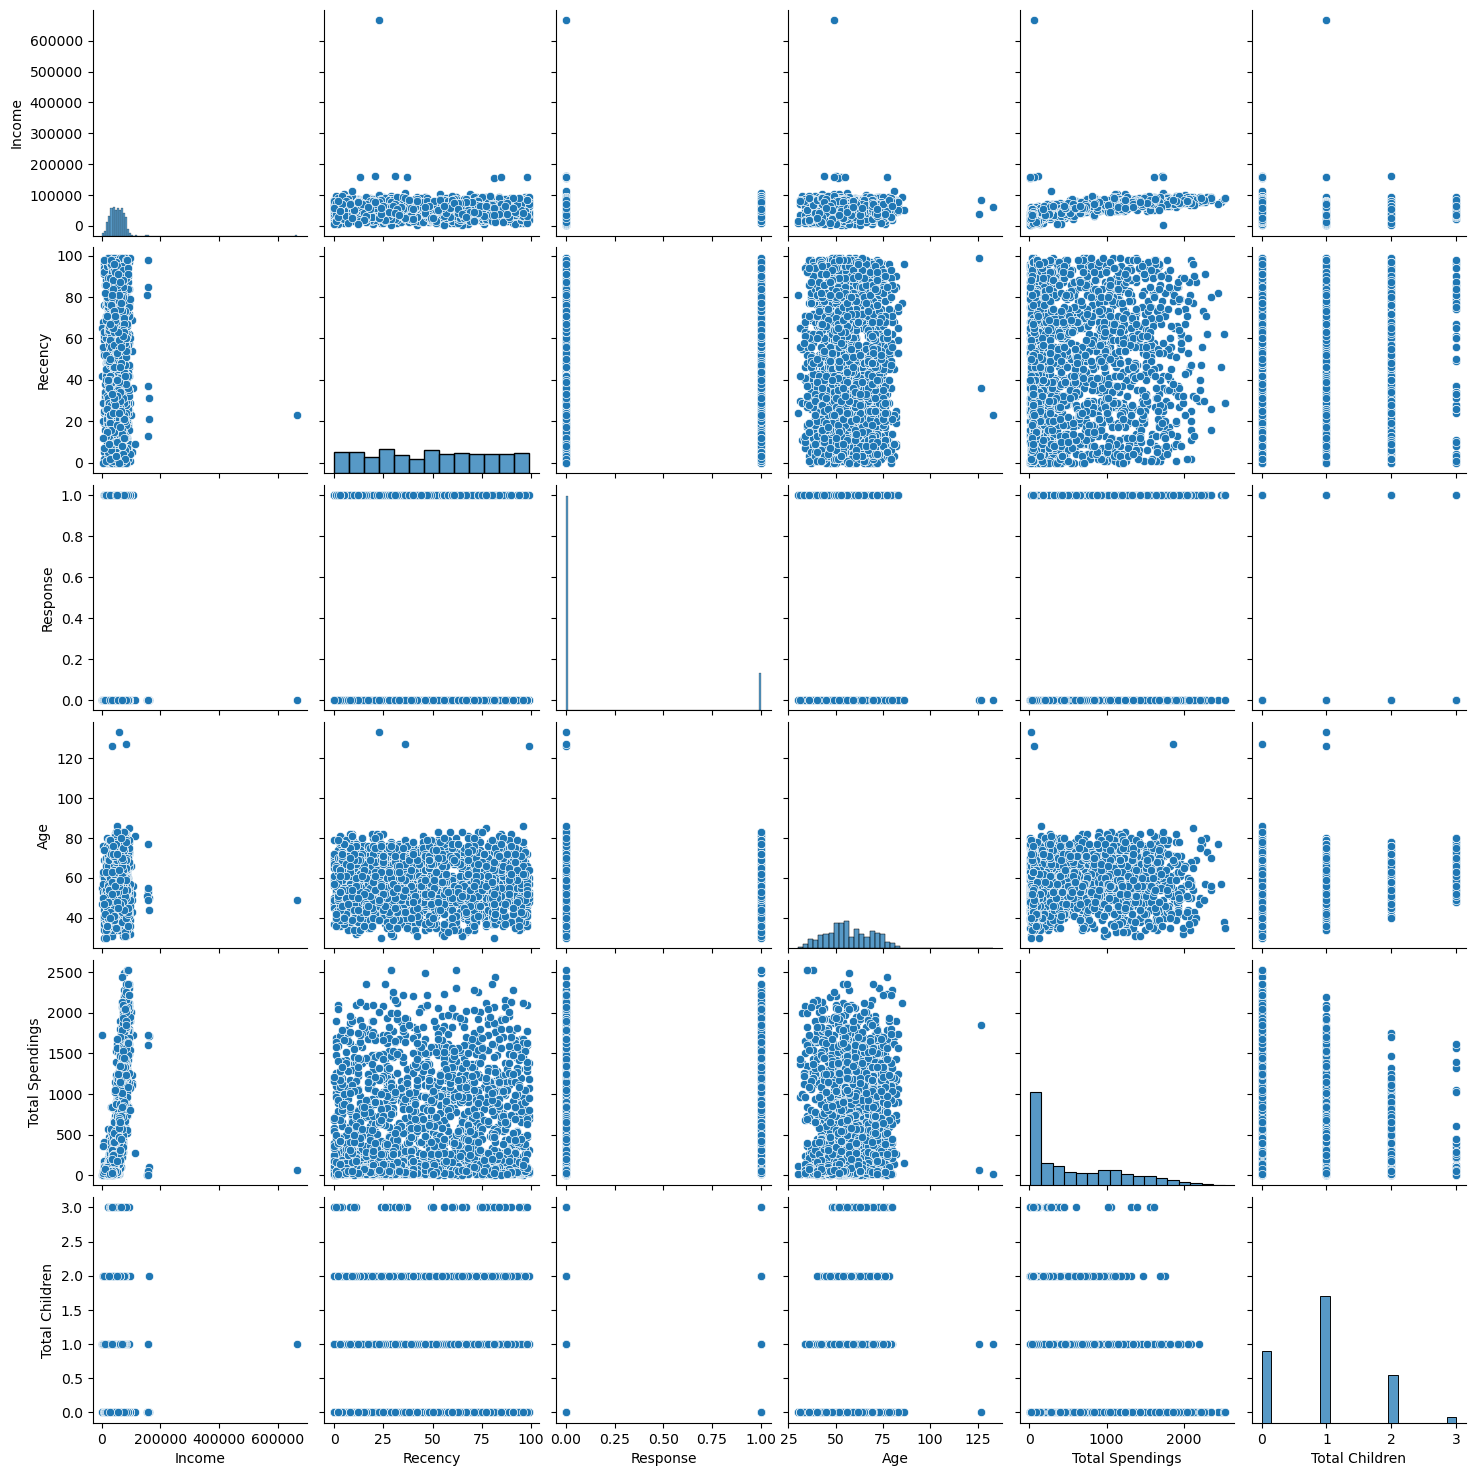

In [19]:
# relative plots of some features-  pair plots
cols = ["Income", "Recency", "Response", "Age", "Total Spendings", "Total Children"]
sns.pairplot(df_cleaned[cols])

In [20]:
# Remove Outliers
print("data size with outliers:", len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned["Income"] < 600_000)]
df_cleaned = df_cleaned[(df_cleaned["Age"] < 90)]

print("data size without outliers:", len(df_cleaned))


data size with outliers: 2240
data size without outliers: 2236


# 5. Heatmap

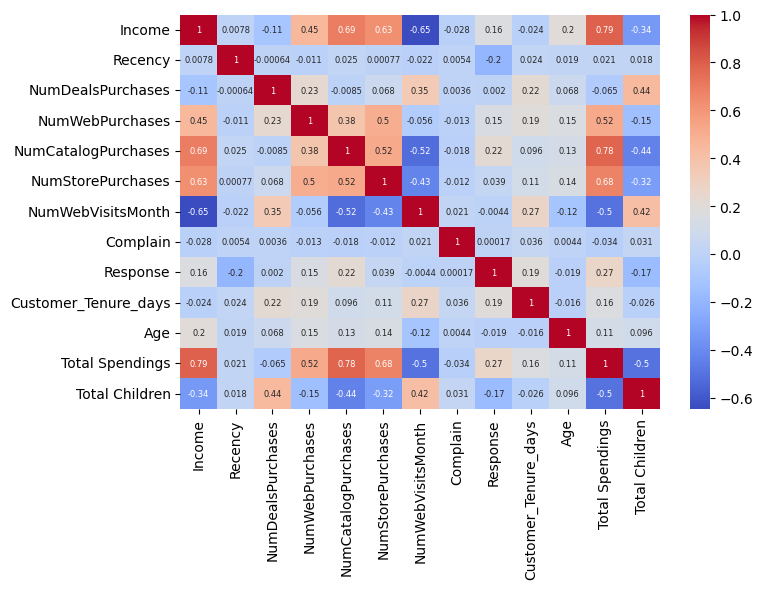

In [21]:
corr = df_cleaned.corr(numeric_only = True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    cmap = "coolwarm",
    annot = True,
    annot_kws = {"size" : 6}
)
plt.tight_layout()


# 6. One Hot Encoding 

In [22]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()

cat_cols = ["Education","Marital_Status"]
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [23]:
enc_df = pd.DataFrame(
    enc_cols.toarray(),
    columns = ohe.get_feature_names_out(cat_cols),
    index = df_cleaned.index
)

In [24]:
df_encoded = pd.concat([df_cleaned.drop(columns = cat_cols), enc_df], axis=1)

In [25]:
df_encoded.head(7)

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Customer_Tenure_days,Age,Total Spendings,Total Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Marital_Status_Alone,Marital_Status_Partner
0,58138.0,58,3,8,10,4,7,0,1,663,69,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,113,72,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,312,61,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,139,42,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,161,45,422,1,0.0,1.0,0.0,0.0,1.0
5,62513.0,16,2,6,4,10,6,0,0,293,59,716,1,0.0,1.0,0.0,0.0,1.0
6,55635.0,34,4,7,3,7,6,0,0,593,55,590,1,1.0,0.0,0.0,1.0,0.0


# 7. Scaling

In [26]:
from sklearn.preprocessing import StandardScaler

X = df_encoded

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 8. Visualize

In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 3)
X_pca = pca.fit_transform(X_scaled)

pca.explained_variance_ratio_
# not a good variance in 3d approx 44% captures information 

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d projection')

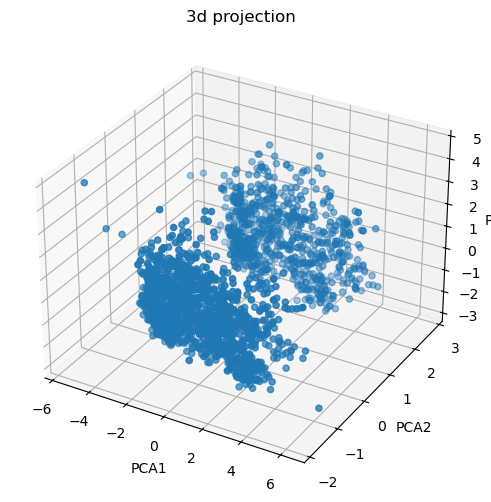

In [28]:
fig = plt.figure(figsize = (8,6))

ax = fig.add_subplot(111, projection = "3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

# 9. Analyze K Value

# Elbow Method

In [53]:
from sklearn.cluster import KMeans

wcss = []

for k in range (1,11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

Text(0.5, 1.0, 'curve')

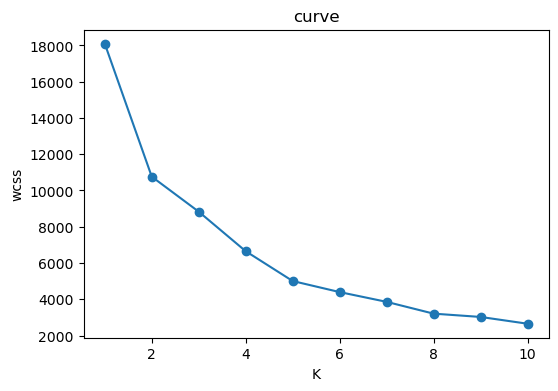

In [54]:
plt.figure(figsize = (6,4))
plt.plot(range(1,11), wcss, marker = 'o')
plt.xlabel("K")
plt.ylabel("wcss")
plt.title("curve")

In [55]:
from kneed import KneeLocator

knee = KneeLocator(range(1,11), wcss, curve = "convex", direction = "decreasing")
optimal_k = knee.elbow
print("best k =",optimal_k) 

best k = 4


# Silhouette Score

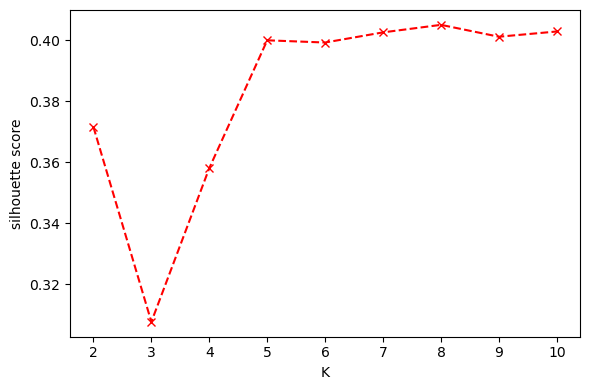

In [51]:
from sklearn.metrics import silhouette_score

scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

# Plot scores vs K
plt.figure(figsize = (6,4))
plt.plot(range(2,11), scores, marker = "x", linestyle = '--', color = 'red')
plt.xlabel('K')
plt.ylabel("silhouette score")
plt.tight_layout()

Text(0, 0.5, 'SS')

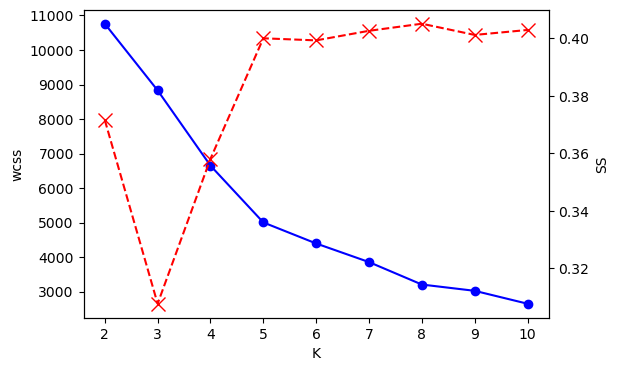

In [75]:
# Combined Plot
k_range = range(2,11)
fig, ax1 = plt.subplots(figsize = (6,4))
ax1.plot(k_range, wcss[1:], marker = 'o', color = 'blue')
ax1.set_xlabel("K")
ax1.set_ylabel("wcss")

ax2 = ax1.twinx()
ax2.plot(k_range, scores, marker = 'x', color = 'red', linestyle = '--', markersize = 10)
ax2.set_ylabel("SS")

# Clustering

In [85]:
# KMeans
kmeans = KMeans(n_clusters = 4, random_state = 42)
labels_kmeans = kmeans.fit_predict(X_pca)

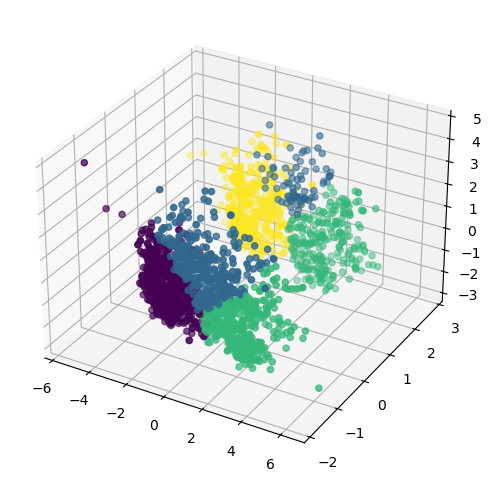

In [86]:
fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111, projection = '3d')
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2] , c = labels_kmeans)

In [89]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering
agg_clf = AgglomerativeClustering(n_clusters = 4, linkage = 'ward')
labels_agg = agg_clf.fit_predict(X_pca)

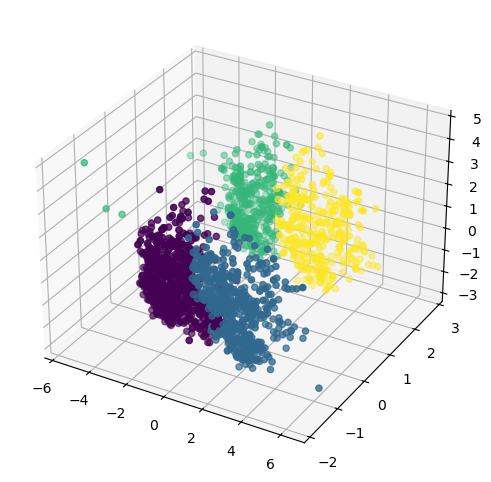

In [90]:
fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111, projection = '3d')
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2] , c = labels_agg)

# Characterisation of Clusters

In [92]:
X["clusters"] = labels_agg

In [95]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Customer_Tenure_days,Age,Total Spendings,Total Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Marital_Status_Alone,Marital_Status_Partner,clusters
0,58138.0,58,3,8,10,4,7,0,1,663,69,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,113,72,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,312,61,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,139,42,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,161,45,422,1,0.0,1.0,0.0,0.0,1.0,0


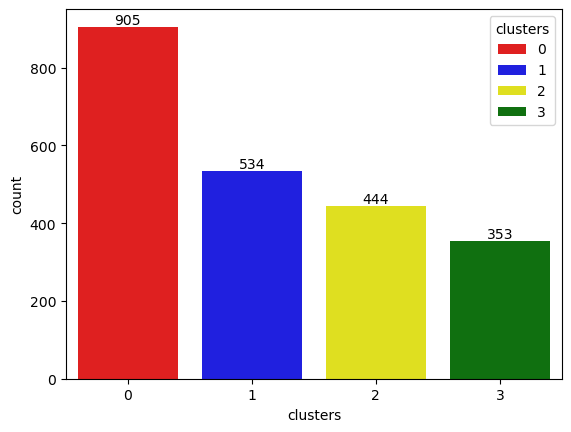

In [108]:
pal = ['red', 'blue', 'yellow', 'green']
ax = sns.countplot(x = X["clusters"], palette = pal, hue = X["clusters"])

for i in range(0,4):
    ax.bar_label(ax.containers[i])

<Axes: xlabel='Total Spendings', ylabel='Income'>

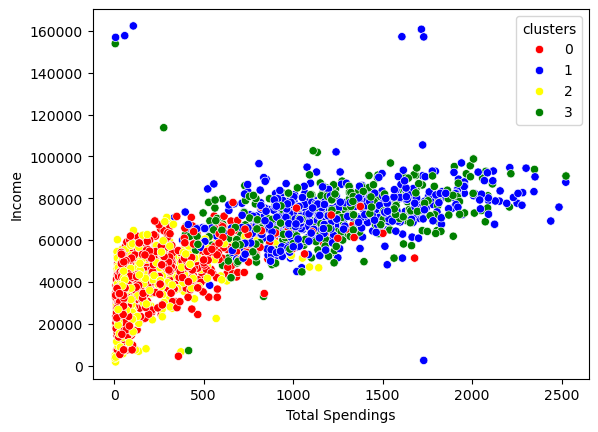

In [112]:
# income and total spendings patterns
sns.scatterplot(x=X['Total Spendings'], y= X['Income'], hue = X['clusters'], palette = pal)

In [113]:
# Cluster Summary

cluster_summary = X.groupby("clusters").mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response  Customer_Tenure_days        Age  Total Spendings  \
cl